In [2]:
import pandas as pd
from sqlalchemy import create_engine , text
from sqlalchemy.engine import URL

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

url = URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=3306,
    database="banking_analytics"
)

engine = create_engine(url)

In [3]:
customers = pd.read_sql("SELECT * FROM customers", engine)
accounts = pd.read_sql("SELECT * FROM accounts", engine)
loans = pd.read_sql("SELECT * FROM loans", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)

In [4]:
# merging data of customer table and loan table
ml_data = customers.merge(
    loans,
    on = "customer_id",
    how = "inner"
)
ml_data.shape

(100000, 30)

In [5]:
ml_data = ml_data.rename(columns={
    "loan_status_x": "customer_loan_status",
    "loan_status_y": "loan_status"
})

In [6]:
ml_data = ml_data[
    ml_data["loan_status"].isin(["Approved" , "Rejected"])
].copy()

In [7]:
ml_data["loan_status"].value_counts()

loan_status
Approved    41149
Rejected    19530
Name: count, dtype: int64

In [8]:
ml_data.columns

Index(['customer_id', 'full_name', 'gender', 'dob', 'age', 'city', 'state',
       'mobile', 'email', 'pan_number', 'aadhaar_number', 'marital_status',
       'occupation', 'annual_income', 'cibil_score', 'account_type',
       'account_number', 'ifsc_code', 'branch_name', 'account_opening_date',
       'account_balance', 'customer_loan_status', 'loan_id', 'loan_type',
       'loan_amount', 'interest_rate', 'tenure_months', 'emi', 'loan_status',
       'loan_start_date'],
      dtype='object')

In [9]:
features = [
    "gender",
    "age",
    "marital_status",
    "occupation",
    "annual_income",
    "cibil_score",
    "account_type",
    "account_balance",
    "loan_type",
    "loan_amount",
    "interest_rate",
    "tenure_months",
    "emi"
]

X = ml_data[features]
y = ml_data["loan_status"]

In [10]:
X.shape

(60679, 13)

<h1> Train and Test Split</h1>

In [11]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((48543, 13), (12136, 13), (48543,), (12136,))

<h1>Preprocessing</h1>
<h3>categorical columns ko One-Hot Encoding karenge and numerical columns ko Scaling karenge.</h3>

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [14]:
categorical_features = [
    "gender",
    "marital_status",
    "occupation",
    "account_type",
    "loan_type"
]

numerical_features = [
    "age",
    "annual_income",
    "cibil_score",
    "account_balance",
    "loan_amount",
    "interest_rate",
    "tenure_months",
    "emi"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)

In [16]:
X_test_processed = preprocessor.transform(X_test)

In [17]:
X_train_processed.shape, X_test_processed.shape

((48543, 856), (12136, 856))

In [18]:
X_train_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 631059 stored elements and shape (48543, 856)>

In [19]:
y_train.value_counts()

loan_status
Approved    32919
Rejected    15624
Name: count, dtype: int64

In [20]:
y_train_encoded = y_train.map({
    "Approved": 1,
    "Rejected": 0
})

y_test_encoded = y_test.map({
    "Approved": 1,
    "Rejected": 0
})

In [21]:
y_train_encoded = y_train.map({
    "Approved": 1,
    "Rejected": 0
})

y_test_encoded = y_test.map({
    "Approved": 1,
    "Rejected": 0
})

In [22]:
y_train_encoded.value_counts()

loan_status
1    32919
0    15624
Name: count, dtype: int64

<h1>Train the model LOGISTIC REGRASSION</h1>

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


In [24]:
# train the data
model.fit(X_train_processed , y_train_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
# now predict the data
y_pred = model.predict(X_test_processed)

In [26]:
y_pred[:10]

array([1, 1, 0, 1, 1, 1, 1, 1, 0, 1])

<h1>Model evalution</h1>
        <h2>accuracy Score</h2>

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

accuracy

0.8559657218193804

<h2>Confusion Matrix</h2>

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

cm

array([[2810, 1096],
       [ 652, 7578]])

<h1>Classification report</h1><br>
<h2>Approved ko kitna sahi predict kiya? <br>
Rejected ko kitna sahi predict kiya?</h2>

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76      3906
           1       0.87      0.92      0.90      8230

    accuracy                           0.86     12136
   macro avg       0.84      0.82      0.83     12136
weighted avg       0.85      0.86      0.85     12136



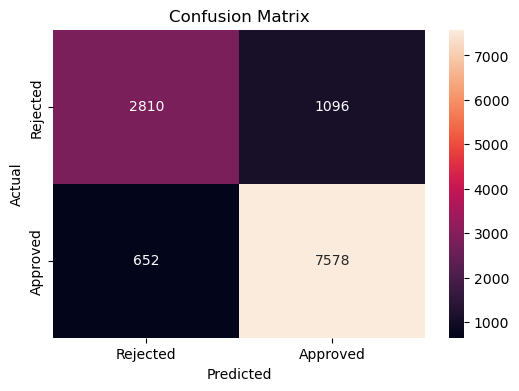

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<h1> Now we will try new model (Decision tree Classifier)</h1>

In [31]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(
    random_state=42
)

In [32]:
model_dt.fit(X_train_processed , y_train_encoded)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred_dt = model_dt.predict(X_test_processed)

In [34]:
y_pred_dt[:10]

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1])

<h1> Check the Accuracy of Decision Tree Model</h1>

In [35]:
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test_encoded , y_pred_dt)
accuracy_dt

0.998681608437706

<h2>Overfitting check</h2>

In [36]:
y_train_pred_dt = model_dt.predict(X_train_processed)

train_accuracy_dt = accuracy_score(
    y_train_encoded,
    y_train_pred_dt
)

train_accuracy_dt

1.0

<h2>Limit decision tree depth</h2>

In [37]:
model_dt_limited = DecisionTreeClassifier(
    max_depth = 10,
    random_state = 42
)

In [38]:
# train the mdoel
model_dt_limited.fit(
    X_train_processed,
    y_train_encoded
)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_pred_dt_limited = model_dt_limited.predict(X_test_processed)
y_pred_dt_limited[:10]

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1])

<h1>Check the Accuracy</h1>

In [40]:
accuracy_dt_limited = accuracy_score(
    y_test_encoded,
    y_pred_dt_limited
)

accuracy_dt_limited

0.9987640079103494

In [41]:
y_train_pred_dt_limited = model_dt_limited.predict(X_train_processed)

train_accuracy_dt_limited = accuracy_score(
    y_train_encoded,
    y_train_pred_dt_limited
)

train_accuracy_dt_limited

0.9998969985373792

<h2>### 11.6.1 Confusion Matrix</h2>

In [42]:
cm_dt = confusion_matrix(
    y_test_encoded,
    y_pred_dt_limited
)

cm_dt

array([[3899,    7],
       [   8, 8222]])

<h2>### 11.6.2 Classification Report</h2>

In [43]:
print(classification_report(
    y_test_encoded,
    y_pred_dt_limited
))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3906
           1       1.00      1.00      1.00      8230

    accuracy                           1.00     12136
   macro avg       1.00      1.00      1.00     12136
weighted avg       1.00      1.00      1.00     12136



<h1>## 12. Feature Importance</h1>
<p>Isse pata chalega ki Decision Tree kis features ke basis par loan approval decide kar raha hai.</p>


In [44]:
feature_importance = model_dt_limited.feature_importances_

feature_importance

array([1.76483512e-04, 2.68722912e-01, 5.26880871e-01, 0.00000000e+00,
       1.87555634e-01, 1.51762754e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.83586454e-05,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       9.16811257e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.58402724e-05,
      

In [45]:
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model_dt_limited.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(10)

,feature,importance
2,num__cibil_score,0.526881
1,num__annual_income,0.268723
4,num__loan_amount,0.187556
5,num__interest_rate,0.015176
0,num__age,0.000176
839,cat__occupation_Wholesale and Retail Buyer,0.000102
11,cat__marital_status_Single,0.000098
434,cat__occupation_Lawyer,0.000094
300,cat__occupation_Farm Labor Contractor,0.000094
543,cat__occupation_Nuclear Medicine Technologist,0.000093


<h2>## 13. Final Model Evaluation</h2>

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

cm_final = confusion_matrix(
    y_test_encoded,
    y_pred_dt_limited
)

print("Confusion Matrix:")
print(cm_final)

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_dt_limited
))

Confusion Matrix:
[[3899    7]
 [   8 8222]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3906
           1       1.00      1.00      1.00      8230

    accuracy                           1.00     12136
   macro avg       1.00      1.00      1.00     12136
weighted avg       1.00      1.00      1.00     12136



<h1>14. Model Comparison</h1>

# model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (max_depth=10)"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt_limited
    ]
})

model_comparison

In [48]:
model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Decision Tree (max_depth=10),0.998764
0,Logistic Regression,0.855966


<p> <h1>## 15. Final Model Selection</h1>

Based on the model comparison, the Decision Tree Classifier with `max_depth=10` is selected as the final model because it achieved the highest test accuracy of approximately 99.88%, compared to 85.60% for Logistic Regression.</p>

<h2>16. Save Final Model & Preprocessor</h2>

In [63]:
import joblib
joblib.dump(model_dt_limited , "loan_approval_model.pkl")
joblib.dump(preprocessor, "loan_approval_preprocessor.pkl")

['loan_approval_preprocessor.pkl']

In [64]:
import os

print("Model saved:", os.path.exists("loan_approval_model.pkl"))
print("Preprocessor saved:", os.path.exists("loan_approval_preprocessor.pkl"))

Model saved: True
Preprocessor saved: True


<h1>## 17. New Customer Prediction</h1>

In [66]:
new_customer = pd.DataFrame([{
    "gender": "Male",
    "age": 30,
    "marital_status": "Single",
    "occupation": "Software Developer",
    "annual_income": 800000,
    "cibil_score": 750,
    "account_type": "Savings",
    "account_balance": 200000,
    "loan_type": "Personal Loan",
    "loan_amount": 500000,
    "interest_rate": 10,
    "tenure_months": 60,
    "emi": 10624
}])

new_customer

,gender,age,marital_status,occupation,annual_income,cibil_score,account_type,account_balance,loan_type,loan_amount,interest_rate,tenure_months,emi
0,Male,30,Single,Software Developer,800000,750,Savings,200000,Personal Loan,500000,10,60,10624


<h2>Step 18: Preprocess New Customer</h2>

In [67]:
new_customer_processed = preprocessor.transform(new_customer)

new_customer_processed.shape

(1, 856)

In [69]:
prediction = model_dt_limited.predict(new_customer_processed)

if prediction[0] == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Rejected")

Loan Status: Approved
